Tópicos Avançados em IA

Rayssa Coelho(BEC): Dataset Dermatology

1. Setup e Importações

In [54]:
!pip install -r requirements_av.txt

In [55]:
import pandas as pd          #manipular dados (dataframe)
import numpy as np           #cálculos
import wandb                 #rastrear, visualizar e gerenciar experimentos de ML
import kagglehub             #acessar datasets do Kaggle
import shutil # serve para mexer com arquivos e pastas
import os     # para lidar com caminhos de arquivos e diretórios
from dotenv import load_dotenv # para carregar variáveis de ambiente de um arquivo .env

In [56]:
import matplotlib.pyplot as plt # gráficos
import seaborn as sns # gráficos
import random # para gerar números aleatórios
from sklearn.model_selection import train_test_split # para dividir os dados em treino e teste
from sklearn.impute import SimpleImputer # para tratar valores faltantes
from sklearn.feature_selection import mutual_info_regression # para calcular a importância das features usando mutual information
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

2. Adicionando o Dataset

In [4]:
import kagglehub # Download da ultima versão do kagglehub 
path = kagglehub.dataset_download("olcaybolat1/dermatology-dataset-classification") 
print("Path to dataset files:", path)

Path to dataset files: C:\Users\rayco\.cache\kagglehub\datasets\olcaybolat1\dermatology-dataset-classification\versions\5


In [57]:
import shutil # serve para mexer com arquivos e pastas
import os     # para lidar com caminhos de arquivos e diretórios
from dotenv import load_dotenv # para carregar variáveis de ambiente de um arquivo .env

# carrega as variáveis de ambiente do arquivo .env
load_dotenv()

# caminho que o kagglehub retornou
source_path = path  

# destino dentro do seu projeto
dest_path = os.path.join(os.getcwd(), "data")

# copia tudo pra pasta data
shutil.copytree(source_path, dest_path, dirs_exist_ok=True)

print("Dataset copiado para:", dest_path)

Dataset copiado para: c:\Users\rayco\Desktop\atividades\aulas_ia\learning_ai\projeto_avaliacao\data


In [69]:
df_raw = pd.read_csv( # lê o arquivo CSV
     "data/dermatology_database_1.csv",
    low_memory=False # evita avisos de tipos de dados mistos
)
print(f"Shape: {df_raw.shape}") # mostra o número de linhas e colunas
print(f"Columns: {list(df_raw.columns[:5])}...") # mostra os nomes das primeiras 5 colunas
df_raw.head() # mostra as primeiras 5 linhas do dataframe

Shape: (366, 35)
Columns: ['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon']...


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [19]:
df_raw.describe() # mostra estatísticas básicas das colunas numéricas

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


Nota-se que a coluna Age não apareceu, pois não apresenta apenas números, ou seja, tem valores faltantes identificados com "?"

3. Login no W&B e Criação Artefato

In [9]:
import os
from dotenv import load_dotenv # para carregar variáveis de ambiente de um arquivo .env
import wandb

API_KEY = os.getenv("WANDB_API_KEY") # pega a chave da API do W&B do arquivo .env
wandb.login(key=API_KEY) 

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\rayco\_netrc
wandb: Currently logged in as: raycoelho (raycoelho-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [70]:
# Inicializa um novo run no W&B para esta etapa de carregamento dos dados
wandb.init(
    project="mlops-project-dermatology", # nome do projeto no W&B
    job_type="load_raw", # tipo do job (pode ser "load_raw", "preprocess", "train", etc.)
    name="load_raw" # nome do run (pode ser "load_raw", "preprocess", "train", etc.
)

# Cria um novo artifact para o dataset bruto
artifact = wandb.Artifact( # cria um novo artifact
    name="raw_data", # artifact name (versioned automatically
    type="dataset", # tipo do artifact (pode ser "dataset", "model", "code", etc.)
    description="Dermatology raw dataset from Kaggle"
)
temp_path = "temp_raw.csv" # caminho temporário para salvar o CSV do dataframe
df_raw.to_csv(temp_path, index=False) # salva o dataframe como CSV sem o índice
artifact.add_file(temp_path) # adiciona o arquivo CSV ao artifact

# Log the artifact to W&B
wandb.log_artifact(artifact) # faz o upload do artifact para o W&B

# Log summary statistics visible on the W&B dashboard
wandb.summary["rows"] = len(df_raw) # número de linhas
wandb.summary["columns"] = list(df_raw.columns) # lista de colunas (pode ser truncada se for muito longa)
wandb.finish() # finaliza o run atual no W&B

print("Raw data artifact saved to W&B.")

rows,366


Raw data artifact saved to W&B.


Obs: O arquivo temporário (temp_raw.csv) é criado porque o método wandb.Artifact.add_file() espera um caminho para um arquivo no sistema de arquivos local. O df_raw é um objeto pandas.DataFrame que existe apenas na memória. Para que o Weights & Biases possa rastrear e versionar esse DataFrame como um artefato, ele precisa primeiro ser salvo em um arquivo. Criar um arquivo temporário é uma prática comum para fazer isso sem sobrecarregar o diretório de trabalho com arquivos intermediários permanentes.

4. Análise Exploratória dos Dados Brutos

Text(0.5, 1.0, 'Distribution of Classes')

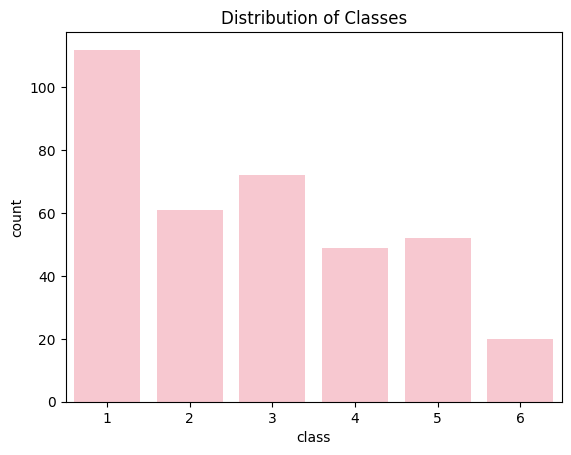

In [71]:
#Gráfico de barras para a distribuição das classes
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df_raw['class'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Classes") # título do gráfico

Text(0.5, 0.98, 'Histograms of Numerical Features')

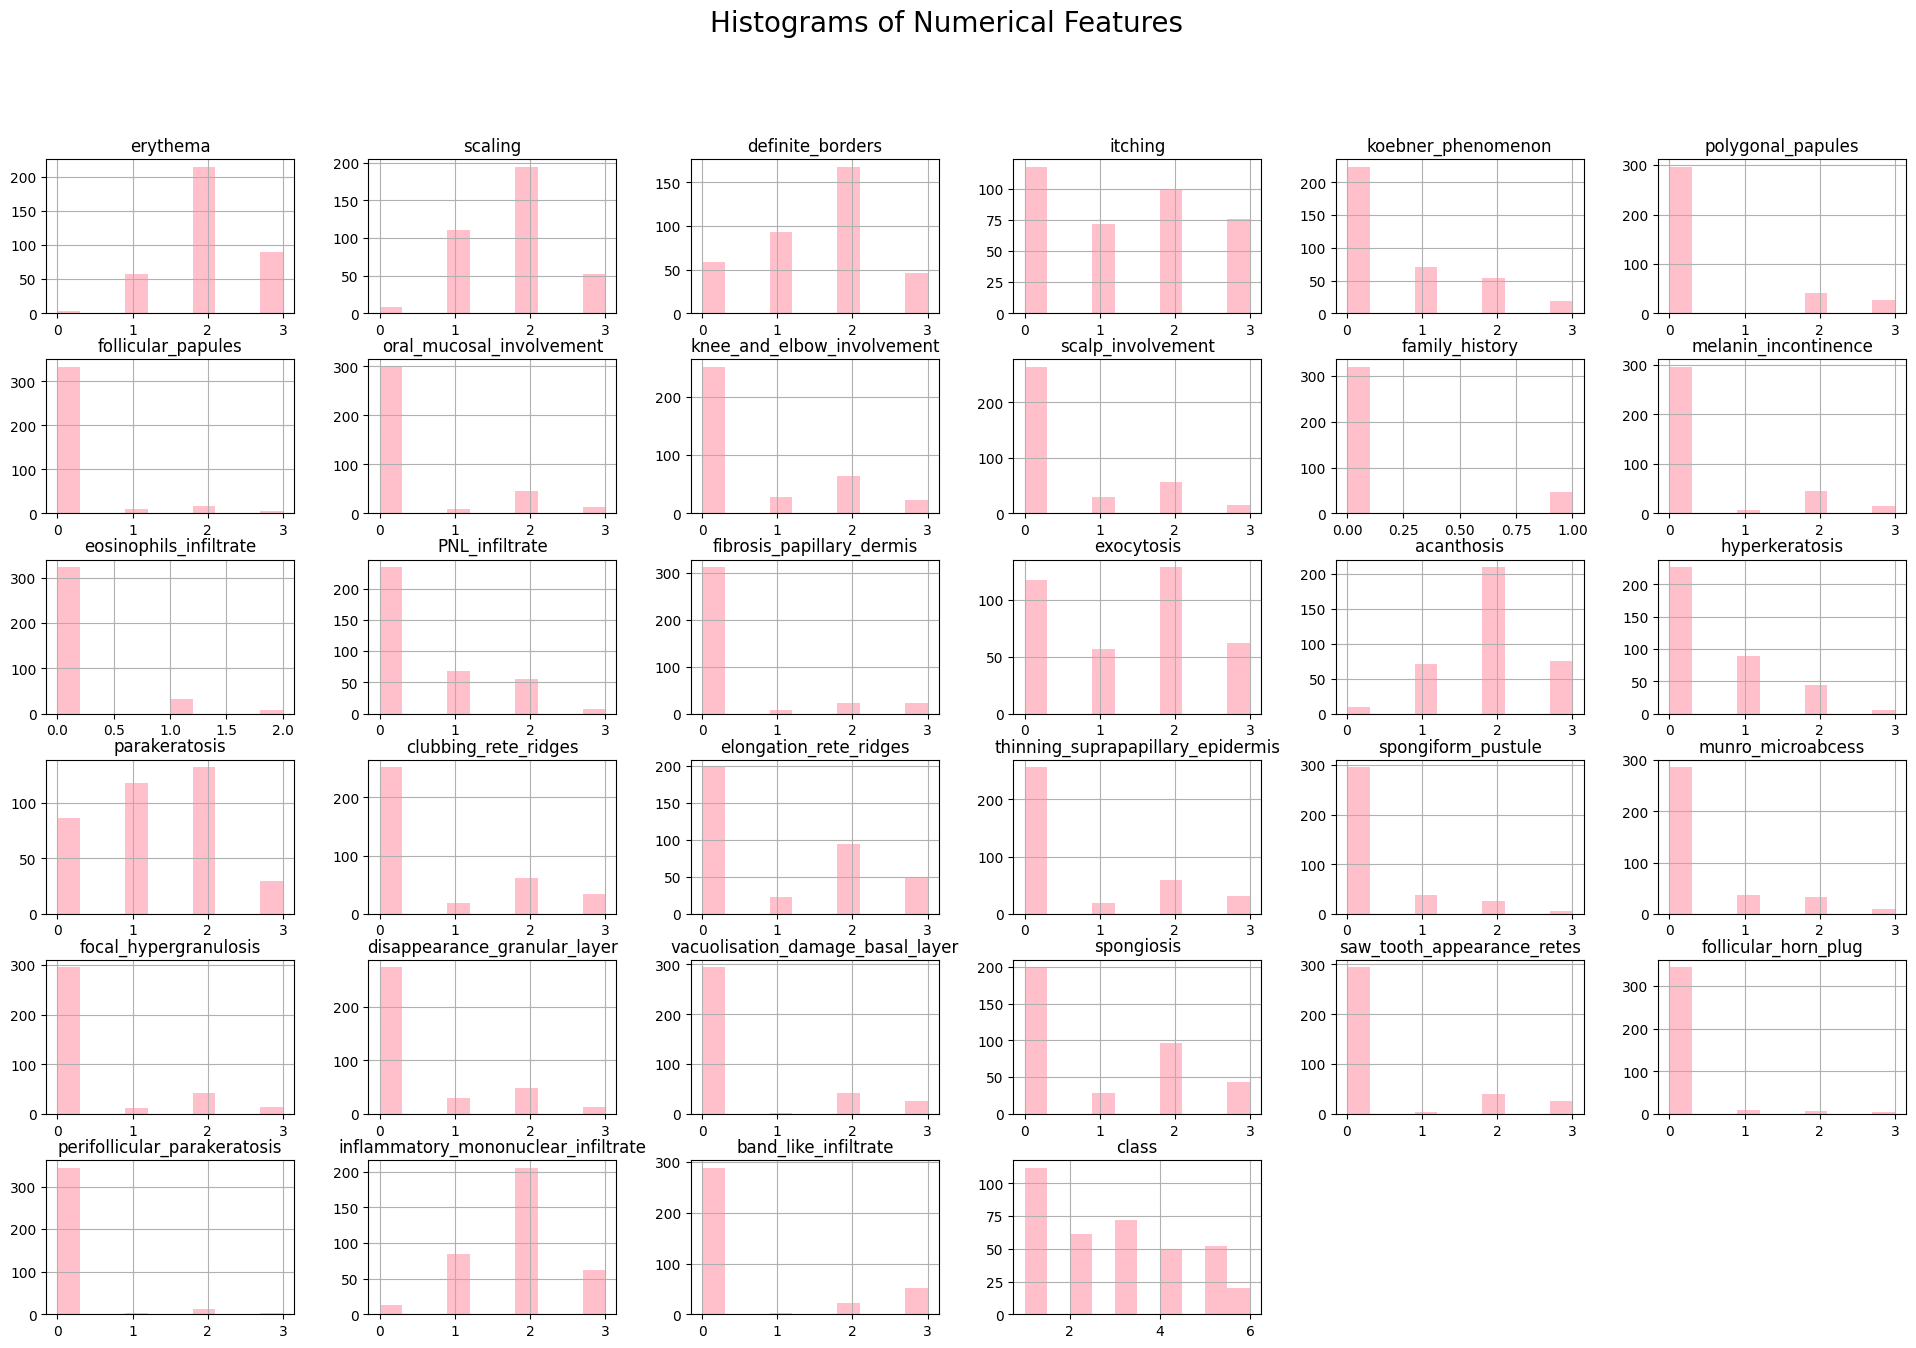

In [72]:
#Histogramas para colunas numéricas
df_raw.hist(figsize=(24,15), color="pink") # mostra histogramas para todas as colunas numéricas do dataframe, com um tamanho de figura grande para melhor visualização
plt.suptitle("Histograms of Numerical Features", fontsize=20) # título geral para os histogramas

5. Limpeza de Dados

Text(0, 0.5, 'Age')

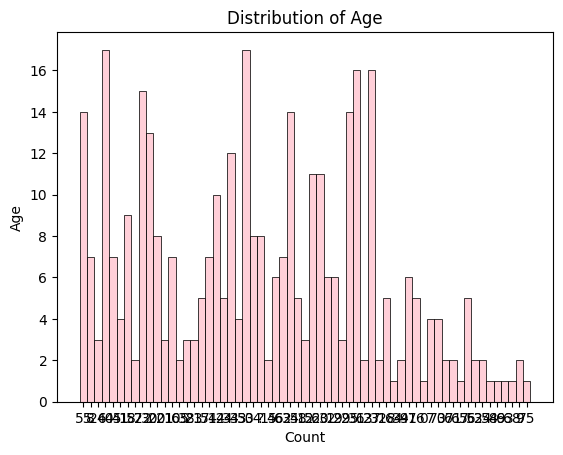

In [77]:
sns.histplot(x=df_raw['age'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Age") # título do gráfico
plt.xlabel("Count") # rótulo do eixo x
plt.ylabel("Age") # rótulo do eixo y

Como visto na análise anterior o atributo que precisa de correção vai ser a coluna "Age"

In [ ]:
# Remoção de duplicatas e tratamento de valores faltantes

# CORREÇÃO ESSENCIAL: troca '?' por NaN antes de tudo
df_raw['age'] = df_raw['age'].replace('?', np.nan) # substitui os valores '?' por NaN para que possam ser tratados como valores faltantes
df_raw['age'] = pd.to_numeric(df_raw['age'])  # converte para número

def remove_duplicates(df): # remove linhas duplicadas do dataframe
    before = len(df)        # salva número original de linhas
    df = df.drop_duplicates() # remove todas as linhas duplicadas do dataframe
    print(f"Removed {before - len(df)} duplicates") # imprime quantas linhas foram removidas
    return df # retorna o dataframe sem duplicatas

def handle_missing_values(df, strategy='median', threshold=0.5): # trata valores faltantes
    missing_frac = df.isnull().median() # calcula a fração de valores faltantes por coluna
    cols_to_drop = missing_frac[missing_frac > threshold].index.tolist() # identifica colunas com mais de 50% de valores faltantes
    df = df.drop(columns=cols_to_drop) # remove essas colunas do dataframe
    print(f"Dropped columns: {cols_to_drop}") # imprime quais colunas foram removidas 
    numeric_cols = df.select_dtypes(include=[np.number]).columns # seleciona apenas as colunas numéricas
    imputer = SimpleImputer(strategy=strategy) # cria um imputer para preencher os valores faltantes usando a estratégia escolhida (mediana)
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols]) # preenche os valores faltantes nas colunas numéricas usando a estratégia escolhida (média, mediana, etc.)
    cat_cols = df.select_dtypes(include=['object']).columns # seleciona apenas as colunas do tipo objeto
    df[cat_cols] = df[cat_cols].fillna('missing') # preenche os valores faltantes com 'missing'
    return df

#executando
df_clean = remove_duplicates(df_raw) # remove linhas duplicadas
df_clean = handle_missing_values(df_clean, strategy='median', threshold=0.5) # trata valores faltantes
print(f"Cleaned dataset shape: {df_clean.shape}") # mostra o número de linhas e colunas do dataset limpo

# confirma que não sobrou nulo
print(f"Nulos restantes: {df_clean.isnull().sum().sum()}")

Removed 0 duplicates
Dropped columns: []
Cleaned dataset shape: (366, 35)
Nulos restantes: 0


Text(0, 0.5, 'Count')

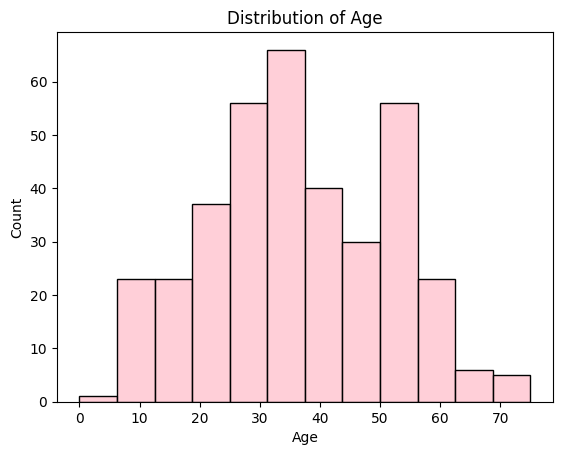

In [ ]:
# Gráfico de barras para a distribuição das Idades Limpos
sns.histplot(x=df_clean['age'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Age") # título do gráfico
plt.xlabel("Age") # rótulo do eixo x
plt.ylabel("Count") # rótulo do eixo y

In [44]:
wandb.init(project="mlops-project-dermatology", job_type="clean_data", name="clean_data") #inicia um novo run no w&b
artifact = wandb.Artifact("clean_data", type="dataset") # novo artifact para o dataset limpo
temp_clean = "temp_clean.csv" # caminho temporário para salvar o CSV do dataframe limpo
df_clean.to_csv(temp_clean, index=False) #salva o dataframe em um csv e impede que o indice seja salvo como coluna
artifact.add_file(temp_clean) # adiciona o arquivo CSV do dataframe limpo ao artifact
wandb.log_artifact(artifact) # faz o upload do artifact para o W&B
wandb.summary["clean_rows"] = len(df_clean) # adiciona ao resumo do W&B o número de linhas do dataset limpo
wandb.finish() # finaliza o run atual no W&B
print("Cleaned data artifact saved to W&B.")

clean_rows,366


Cleaned data artifact saved to W&B.


Text(0, 0.5, 'Count')

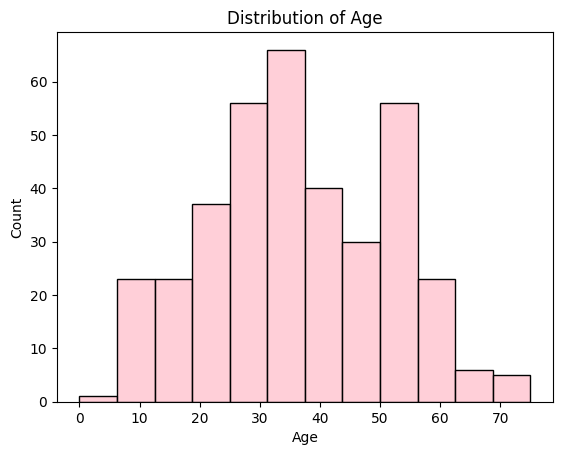

In [89]:
sns.histplot(x=df_clean['age'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Age") # título do gráfico
plt.xlabel("Age") # rótulo do eixo x
plt.ylabel("Count") # rótulo do eixo y

In [88]:
# Tratamento de outliers

from pyparsing import col


def detect_and_treat_outliers_iqr(df_clean, columns, strategy='capping', fator=1.5): # função para detectar e tratar outliers usando o método do intervalo interquartil (IQR)
    # Detecta e trata outliers via IQR.
    # Estratégias: 'capping' | 'mediana' | 'remover', serve para substituir os outliers pelos limites ou pela mediana, ou remover as linhas com outliers
    df_out = df_clean.copy() # para não modificar o original

    for col in columns:
        Q1 = df_out[col].quantile(0.25) # primeiro quartil
        Q3 = df_out[col].quantile(0.75) # terceiro quartil
        IQR = Q3 - Q1 # intervalo interquartil
        li = Q1 - fator * IQR   # limite inferior
        ls = Q3 + fator * IQR   # limite superior

        outliers = ((df_out[col] < li) | (df_out[col] > ls)).sum() # conta quantos outliers existem nessa coluna comparando com os limites se são menores que o limite inferior ou maiores que o limite superior
        print(f"[{col}] Q1={Q1:.1f} | Q3={Q3:.1f} | Limites: [{li:.1f}, {ls:.1f}] | Outliers: {outliers}") # imprime os quartis, limites e número de outliers encontrados
        
        if strategy == 'capping': # substitui os outliers pelos limites
            df_out[col] = df_out[col].clip(lower=li, upper=ls)   # substitui pelos limites

        elif strategy == 'median': # substitui os outliers pela mediana
            mediana = df_out[col].median()
            df_out[col] = df_out[col].where((df_out[col] >= li) & (df_out[col] <= ls), mediana) # substitui os outliers pela mediana usando where para manter os valores dentro dos limites e substituir os outliers

        elif strategy == 'remove': # remove as linhas com outliers
            df_out = df_out[(df_out[col] >= li) & (df_out[col] <= ls)] # mantém apenas as linhas onde os valores estão dentro dos limites, removendo as linhas com outliers

    return df_out
   

# ── executa ───────────────────────────────────────────────────
# só 'age' tem escala contínua; as demais são ordinais (0-3)
colunas_alvo = ['age'] # define quais colunas serão tratadas para outliers (apenas 'age' nesse caso, pois as outras são ordinais com poucos valores possíveis)

df_out = detect_and_treat_outliers_iqr(df_clean, columns=colunas_alvo, strategy='capping') # trata os outliers usando o método do intervalo interquartil (IQR) e a estratégia de capping (substituir pelos limites)

print(f"\nShape após tratamento: {df_clean.shape}") # mostra o número de linhas e colunas do dataset após o tratamento de outliers
print(f"Age — min: {df_clean['age'].min():.0f} | max: {df_clean['age'].max():.0f}") # mostra o valor mínimo e máximo da coluna 'age' após o tratamento de outliers para confirmar que os valores extremos foram tratados
       


[age] Q1=25.0 | Q3=48.0 | Limites: [-9.5, 82.5] | Outliers: 0

Shape após tratamento: (366, 35)
Age — min: 0 | max: 75


Text(0, 0.5, 'Count')

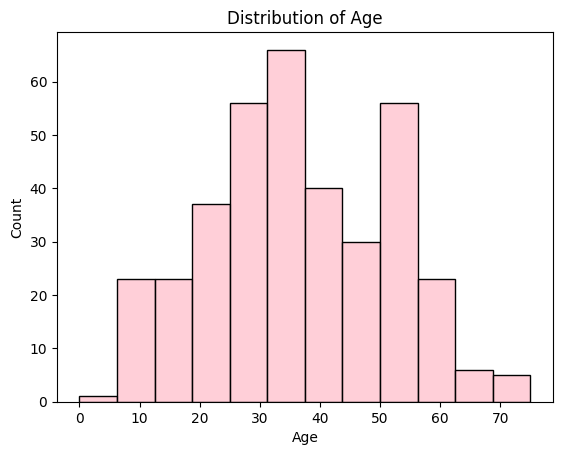

In [90]:
sns.histplot(x=df_out['age'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Age") # título do gráfico
plt.xlabel("Age") # rótulo do eixo x
plt.ylabel("Count") # rótulo do eixo y